# Level 2 — Lesson 3: From Medical Images to Model-Ready Data with MONAI

**AI for Radiotherapy**

**Audience:** You know radiotherapy, medical imaging, basic Python, and the learning concepts from Lessons 1 and 2.

**Teaching time:** ~45–50 minutes  
**Core question:** *How do we turn medical-image files into the representation that a model should actually receive?*

In Lesson 1 we asked:

> **What information should the model receive?**

In Lesson 2 we asked:

> **How does the model learn from that information?**

Now we connect the two:

```text
medical-image files
        ↓
preprocessing
        ↓
sampling / augmentation
        ↓
model-ready tensors
        ↓
PyTorch model
```

This is where **MONAI** becomes useful.

By the end of this lesson, you should be able to:

- organize medical-imaging cases as MONAI dictionaries;
- explain what transforms and transform pipelines are;
- build a preprocessing pipeline with `Compose`;
- explain why aligned images and labels must undergo compatible spatial transforms;
- choose appropriate interpolation for continuous images and discrete masks;
- distinguish deterministic preprocessing from random augmentation;
- explain why patch sampling changes the effective training distribution;
- understand the roles of `Dataset`, `CacheDataset`, and `DataLoader`;
- construct separate training and validation pipelines.

# 0. Setup

This lesson uses a small **synthetic CT-like 3D dataset** that we create inside the notebook.

Why not immediately download a large public dataset?

- the lesson should run on a free Colab account;
- downloading gigabytes of data should not dominate teaching time;
- the goal here is the **pipeline**, not clinical anatomy;
- the files we create are genuine NIfTI files with image data, labels, affine matrices, and anisotropic voxel spacing.

The same MONAI transforms will later work on real NIfTI datasets.

> The synthetic images are teaching data only. They are not anatomically or clinically realistic.

In [ ]:
!pip -q install "monai==1.6.1" nibabel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 24.8 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import torch

import monai
from monai.data import Dataset, CacheDataset, DataLoader
from monai.data.utils import affine_to_spacing
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    ScaleIntensityRanged,
    RandCropByPosNegLabeld,
    RandFlipd,
    RandRotate90d,
    EnsureTyped,
)
from monai.utils import set_determinism

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_determinism(seed=SEED)

print("MONAI:", monai.__version__)
print("PyTorch:", torch.__version__)

MONAI: 1.6.1
PyTorch: 2.11.0+cpu


# 1. Preprocessing with MONAI

In Lessons 1 and 2, we saw that what information we provide to a model — and how we represent it — strongly influences what the model can learn.

Radiotherapy data often contain several spatially related objects: CT, segmentation masks, dose distributions, and sometimes additional image-derived information. These objects need to remain spatially consistent while often requiring **different mathematical treatment**.

Even apparently simple preprocessing steps raise practical questions:

- How should CT, masks, and dose be interpolated when resampling?
- How do we apply the same spatial transform to several aligned objects?
- How do we ensure an intensity transform affects the CT but not the segmentation?
- How do we efficiently repeat expensive preprocessing during training?

MONAI provides reusable building blocks for these tasks.

The objective of this lesson is not to memorize MONAI functions. It is to understand how **transforms, datasets, sampling, and batching** fit together into a medical-imaging data pipeline.

## Radiotherapy data are more than just one 3D image

MONAI can represent one case as a Python `dictionary`, where each `key` identifies the role of one data object.

For a simple segmentation task:

```python
case = {
    "image": "patient001_ct.nii.gz",
    "label": "patient001_seg.nii.gz",
}
```

For radiotherapy:

```python
case = {
    "ct": "patient001_ct.nii.gz",
    "ptv": "patient001_ptv.nii.gz",
    "spinal_cord": "patient001_cord.nii.gz",
    "dose": "patient001_dose.nii.gz",
}
```

Different transforms can then act on different combinations of keys.

> **The dictionary makes the relationship between several spatially aligned objects explicit.**

## Data transforms

A **transform** is an operation that takes some data as input and returns a modified version of that data.

In medical imaging, transforms describe the steps that convert stored data into the representation we want the model to see.

Examples include:

```text
load image from disk
        ↓
change orientation
        ↓
resample voxel spacing
        ↓
scale intensity values
        ↓
crop a patch
        ↓
randomly rotate the image
```

Each step can be thought of as a function:

```python
output = transform(input)
```

For example:

```text
CT with 3 mm slice spacing
        ↓
Spacing transform
        ↓
CT resampled to 2 mm slice spacing
```

### What is a data pipeline?

A **data pipeline** is the complete ordered sequence that takes data from its stored form to the tensors presented to the model:

```text
files → transforms → sampling → batching → model
```

We could write each preprocessing step manually in Python. MONAI instead provides standardized transforms for common medical-imaging operations.

This makes it easier to:

- preserve image metadata;
- apply coordinated spatial transforms to aligned objects;
- apply different transforms to different data types;
- add random augmentation;
- reuse the same preprocessing logic consistently.

### `Compose`: build a pipeline from transforms

MONAI's `Compose` applies transforms one after another:

```python
transforms = Compose([
    LoadImaged(...),
    EnsureChannelFirstd(...),
    Orientationd(...),
    Spacingd(...),
])
```

The output of one transform becomes the input to the next.

> **Transform order matters.**

Some dependencies are obvious — an image must be loaded before it can be resampled — but order can also change the resulting representation. For example:

```text
crop → resample
```

is not necessarily equivalent to:

```text
resample → crop
```

Transforms also differ in how much information they preserve. An orientation change is largely reversible, while cropping, downsampling, or intensity clipping may discard information.

This connects directly to Lesson 1:

> **Transforms are not merely software operations; they encode assumptions about which information should be preserved, standardized, or discarded.**

Some transforms are **deterministic**:

```text
same input → same output
```

Others are **random**:

```text
same input → potentially different output
```

We will use both later in this lesson.

## The `d` in MONAI transform names

You will often encounter both:

```python
LoadImage
LoadImaged
```

or:

```python
Spacing
Spacingd
```

The versions ending in **`d`** operate on dictionaries.

For example:

```python
Spacingd(
    keys=["image", "label"],
    ...
)
```

applies the transform to both entries while preserving the dictionary structure.

This is especially useful in medical imaging because several spatially aligned objects often need coordinated transformations.

# 2. Create a small CT-like NIfTI dataset

We create four synthetic cases with:

- CT-like intensity values;
- a binary segmentation mask;
- anisotropic voxel spacing;
- an LPS-like orientation;
- slightly different spacing and anatomy between cases.

> **You do not need to understand the code in the next cell.** It only creates small example NIfTI files so that we can focus on MONAI rather than data download and file preparation.

The important point is that MONAI will receive ordinary NIfTI files rather than pre-created tensors.

In [ ]:
DATA_DIR = Path("/content/monai_lesson3_data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

def create_synthetic_case(case_id, spacing, seed):
    rng = np.random.default_rng(seed)

    shape = (96, 96, 48)
    x, y, z = np.indices(shape)

    # Small case-to-case variation
    shift_x = rng.integers(-5, 6)
    shift_y = rng.integers(-5, 6)

    # Air background
    ct = np.full(shape, -1000.0, dtype=np.float32)

    # Simple elliptical "body"
    body = (
        ((x - (48 + shift_x)) / 38) ** 2
        + ((y - (48 + shift_y)) / 32) ** 2
        + ((z - 24) / 22) ** 2
    ) < 1

    ct[body] = 0.0 + rng.normal(0, 25, size=body.sum())

    # High-density structure
    bone = (
        ((x - (48 + shift_x)) / 8) ** 2
        + ((y - (34 + shift_y)) / 7) ** 2
        + ((z - 24) / 18) ** 2
    ) < 1


    ct[bone] = 700.0 + rng.normal(0, 70, size=bone.sum())


    # Binary target organ
    organ = (
        ((x - (64 + shift_x)) / 10) ** 2
        + ((y - (48 + shift_y)) / 13) ** 2
        + ((z - 25) / 10) ** 2
    ) < 1

    ct[organ] = 65.0 + rng.normal(0, 15, size=organ.sum())
    label = organ.astype(np.uint8)

    sx, sy, sz = spacing

    # LPS-like orientation: x and y axes point in the negative direction.
    affine = np.array([
        [-sx, 0.0, 0.0, (shape[0] - 1) * sx],
        [0.0, -sy, 0.0, (shape[1] - 1) * sy],
        [0.0, 0.0, sz, 0.0],
        [0.0, 0.0, 0.0, 1.0],
    ])

    image_path = DATA_DIR / f"case_{case_id:02d}_ct.nii.gz"
    label_path = DATA_DIR / f"case_{case_id:02d}_label.nii.gz"

    nib.save(nib.Nifti1Image(ct, affine), image_path)
    nib.save(nib.Nifti1Image(label, affine), label_path)

    return {
        "image": str(image_path),
        "label": str(label_path),
    }


spacings = [
    (1.2, 1.2, 3.0),
    (1.0, 1.0, 2.5),
    (1.4, 1.4, 3.0),
    (1.1, 1.1, 2.0),
]

files = [
    create_synthetic_case(i, spacing, SEED + i)
    for i, spacing in enumerate(spacings)
]

files

[{'image': '/content/monai_lesson3_data/case_00_ct.nii.gz',
  'label': '/content/monai_lesson3_data/case_00_label.nii.gz'},
 {'image': '/content/monai_lesson3_data/case_01_ct.nii.gz',
  'label': '/content/monai_lesson3_data/case_01_label.nii.gz'},
 {'image': '/content/monai_lesson3_data/case_02_ct.nii.gz',
  'label': '/content/monai_lesson3_data/case_02_label.nii.gz'},
 {'image': '/content/monai_lesson3_data/case_03_ct.nii.gz',
  'label': '/content/monai_lesson3_data/case_03_label.nii.gz'}]

## What information is in the file?

The voxel array is only part of a medical image.

The NIfTI affine describes how voxel indices map into physical space and therefore carries information about orientation and voxel spacing.

For example:

```python
image.shape
```

tells us the number of voxels, but not whether increasing an index moves left, right, anterior, posterior, superior, or inferior in physical space.

This is why a medical-imaging pipeline must preserve **spatial metadata**, not just voxel values.

In [ ]:
nii = nib.load(files[0]["image"])

print("Stored array shape:", nii.shape)
print("Axis codes:", nib.aff2axcodes(nii.affine))
print("Voxel spacing:", nii.header.get_zooms()[:3])
print("\nAffine:")
print(nii.affine)

Stored array shape: (96, 96, 48)
Axis codes: ('L', 'P', 'S')
Voxel spacing: (np.float32(1.2), np.float32(1.2), np.float32(3.0))

Affine:
[[ -1.20000005   0.           0.         114.        ]
 [  0.          -1.20000005   0.         114.        ]
 [  0.           0.           3.           0.        ]
 [  0.           0.           0.           1.        ]]


# 3. Load the case with MONAI

We start with only two transforms:

```text
LoadImaged
    ↓
EnsureChannelFirstd
```

`LoadImaged` reads the NIfTI files.

`EnsureChannelFirstd` makes the channel dimension explicit:

```text
[X, Y, Z]
     ↓
[1, X, Y, Z]
```

This connects directly to the channel concept from Lesson 2.

In [ ]:
load_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
])

raw_sample = load_transforms(files[0])

print("Image type:", type(raw_sample["image"]))
print("Image shape:", raw_sample["image"].shape)
print("Label shape:", raw_sample["label"].shape)

print(
    "Image spacing:",
    affine_to_spacing(raw_sample["image"].affine).cpu().numpy(),
)

print(
    "Orientation:",
    nib.aff2axcodes(np.asarray(raw_sample["image"].affine)),
)

print(
    "CT range:",
    float(raw_sample["image"].min()),
    "to",
    float(raw_sample["image"].max()),
)

print(
    "Label values:",
    torch.unique(raw_sample["label"]),
)

Image type: <class 'monai.data.meta_tensor.MetaTensor'>
Image shape: torch.Size([1, 96, 96, 48])
Label shape: torch.Size([1, 96, 96, 48])
Image spacing: [1.20000005 1.20000005 3.        ]
Orientation: ('L', 'P', 'S')
CT range: -1000.0 to 960.4332275390625
Label values: metatensor([0., 1.])


### `MetaTensor`

MONAI has loaded the image as a `MetaTensor`.

A `MetaTensor` behaves like a PyTorch tensor but also carries medical-image metadata such as the affine matrix.

```text
ordinary tensor
    voxel values

MetaTensor
    voxel values
    + spatial metadata
```

This matters because many preprocessing steps modify both.

For example, resampling changes the voxel grid and therefore also changes the affine that describes how that grid maps into physical space.

MONAI can therefore perform spatial transforms while keeping the image data and its physical interpretation linked.

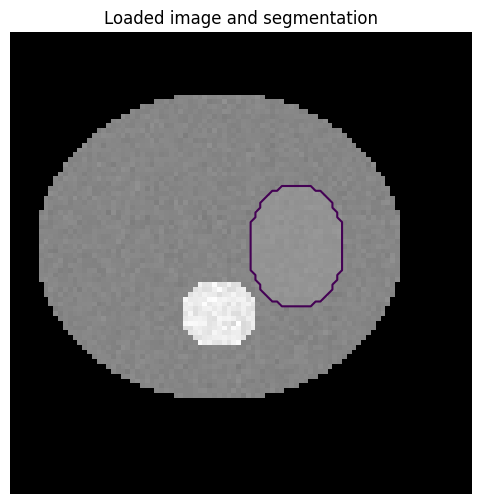

In [ ]:
def show_mid_slice(sample, title=""):
    image = sample["image"][0].detach().cpu().numpy()
    label = sample["label"][0].detach().cpu().numpy()

    z = image.shape[2] // 2

    plt.figure(figsize=(6, 6))
    plt.imshow(image[:, :, z].T, cmap="gray", origin="lower")
    plt.contour(label[:, :, z].T, levels=[0.5])
    plt.title(title)
    plt.axis("off")
    plt.show()

show_mid_slice(raw_sample, "Loaded image and segmentation")

# 4. Build a deterministic preprocessing pipeline

Now we make the representation more consistent across patients.

We will:

1. load image and label;
2. ensure an explicit channel dimension;
3. convert orientation to RAS;
4. resample to a common voxel spacing;
5. map a defined CT intensity range to `[0, 1]`.

These are **deterministic transforms**: the same input should produce the same output every time.

This type of preprocessing is usually also required at inference time, because the trained model expects future data to be represented in the same way.

In [ ]:
base_transforms = Compose([
    LoadImaged(keys=["image", "label"]),

    EnsureChannelFirstd(
        keys=["image", "label"]
    ),

    Orientationd(
        keys=["image", "label"],
        axcodes="RAS",
    ),

    Spacingd(
        keys=["image", "label"],
        pixdim=(1.5, 1.5, 2.0),
        mode=("bilinear", "nearest"),
    ),

    ScaleIntensityRanged(
        keys=["image"],
        a_min=-1000,
        a_max=1000,
        b_min=0.0,
        b_max=1.0,
        clip=True,
    ),

    EnsureTyped(
        keys=["image", "label"]
    ),
])

processed = base_transforms(files[0])

print("Processed image shape:", processed["image"].shape)
print("Processed label shape:", processed["label"].shape)

print(
    "Processed spacing:",
    affine_to_spacing(processed["image"].affine).cpu().numpy(),
)

print(
    "Processed orientation:",
    nib.aff2axcodes(np.asarray(processed["image"].affine)),
)

print(
    "Processed image range:",
    float(processed["image"].min()),
    "to",
    float(processed["image"].max()),
)

print(
    "Processed label values:",
    torch.unique(processed["label"]),
)

Processed image shape: torch.Size([1, 77, 77, 72])
Processed label shape: torch.Size([1, 77, 77, 72])
Processed spacing: [1.5 1.5 2. ]
Processed orientation: ('R', 'A', 'S')
Processed image range: 0.0 to 0.9358454346656799
Processed label values: metatensor([0., 1.])


/usr/local/lib/python3.13/dist-packages/monai/utils/deprecate_utils.py:320: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


## Why do image and label use different interpolation?

Look closely at:

```python
Spacingd(
    keys=["image", "label"],
    pixdim=(1.5, 1.5, 2.0),
    mode=("bilinear", "nearest"),
)
```

The CT represents a **continuous-valued image**. Interpolation between neighbouring values is meaningful.

The segmentation represents **discrete classes**:

```text
0 = background
1 = organ
```

Treating those labels as continuous values during interpolation would create meaningless intermediate values such as:

```text
0.17
0.54
0.82
```

We therefore use:

```text
CT image → interpolating method
label    → nearest-neighbour
```

> **Objects can occupy the same spatial grid but still require different mathematical treatment.**

### Exercise — deliberately use the wrong interpolation

The following pipeline resamples the segmentation with bilinear interpolation.

What do you expect to happen?

In [ ]:
wrong_interpolation = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),

    Spacingd(
        keys=["image", "label"],
        pixdim=(1.5, 1.5, 2.0),
        mode=("bilinear", "bilinear"),   # intentionally wrong for label
    ),

    EnsureTyped(keys=["image", "label"]),
])

wrong = wrong_interpolation(files[0])

wrong_values = torch.unique(wrong["label"])

print("Number of unique label values:", len(wrong_values))
print("First values:", wrong_values[:15])

Number of unique label values: 504
First values: metatensor([0.0000e+00, 1.1579e-12, 2.3685e-12, 3.4738e-12, 1.3246e-07, 1.4901e-07,
        1.6557e-07, 2.6491e-07, 2.6491e-07, 2.9802e-07, 2.9802e-07, 3.3114e-07,
        3.3114e-07, 3.3114e-07, 3.3114e-07])


The problem is not that interpolation is "bad".

The problem is that the interpolation method must match the **meaning of the data**.

This will matter again for radiotherapy:

```text
CT       → continuous image
dose     → continuous field
mask     → discrete class labels
```

Even when all three are spatially aligned, they should not automatically receive identical interpolation settings.

# 5. Deterministic preprocessing versus augmentation

So far, preprocessing has created a defined and consistent representation.

Training pipelines often also include **random augmentation**.

Examples include:

- flips;
- rotations;
- translations;
- intensity perturbations;
- noise.

The purposes are different:

```text
deterministic preprocessing
    create the representation expected by the model
    usually needed during training and inference

random augmentation
    deliberately create plausible variation
    usually used during training only
```

A spatial augmentation must be applied consistently to all spatially aligned objects.

If the CT is rotated but its segmentation is not, the training pair becomes incorrect.

Later, more advanced workflows may use techniques such as test-time augmentation, but that is a separate choice rather than the default.

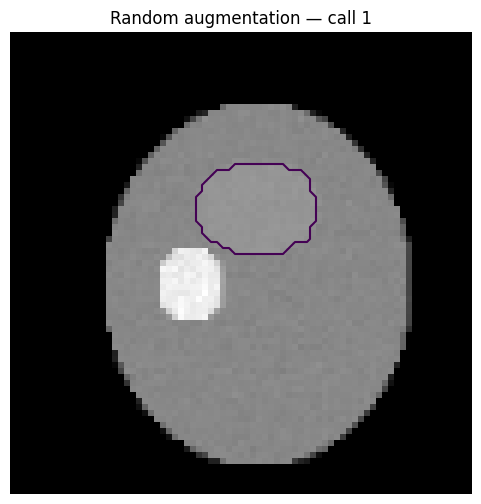

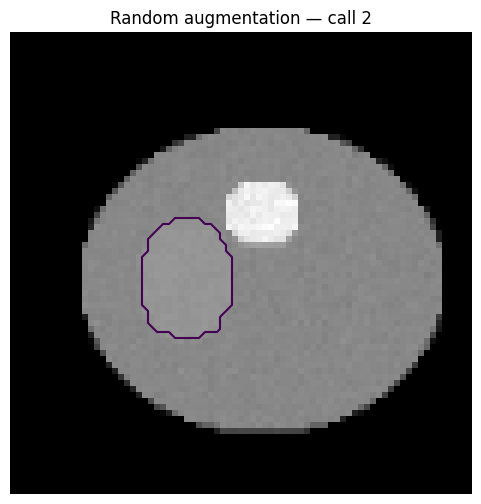

In [ ]:
augmentation_demo = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),

    Spacingd(
        keys=["image", "label"],
        pixdim=(1.5, 1.5, 2.0),
        mode=("bilinear", "nearest"),
    ),

    ScaleIntensityRanged(
        keys=["image"],
        a_min=-1000,
        a_max=1000,
        b_min=0.0,
        b_max=1.0,
        clip=True,
    ),

    RandFlipd(
        keys=["image", "label"],
        prob=0.5,
        spatial_axis=0,
    ),

    RandRotate90d(
        keys=["image", "label"],
        prob=0.5,
        max_k=3,
        spatial_axes=(0, 1),
    ),

    EnsureTyped(keys=["image", "label"]),
])

augmented_a = augmentation_demo(files[0])
augmented_b = augmentation_demo(files[0])

show_mid_slice(augmented_a, "Random augmentation — call 1")
show_mid_slice(augmented_b, "Random augmentation — call 2")

### Not every transform should act on every key

A spatial rotation may need to affect:

```text
CT
segmentation
dose
```

together.

An intensity perturbation designed to mimic CT acquisition variation should usually affect:

```text
CT only
```

Dictionary transforms make this explicit because each transform specifies the keys on which it acts.

> **Spatial consistency does not mean every data object receives the same mathematical operation.**

# 6. Patch sampling is part of the learning problem

Three-dimensional volumes are large.

Instead of training on the entire volume, many medical-imaging pipelines train on smaller **patches**:

```text
full image
    ↓
sample a region
    ↓
model sees only that patch
```

This solves a computational problem — but it also changes the data distribution.

Suppose the target occupies only 1% of the image.

If we sample patches completely at random, many patches may contain no target at all.

That connects directly to Lesson 1:

> **Sampling determines which examples the model experiences during training.**

Also remember:

```text
1 patient
→ many patches
≠ many independent patients
```

Generating more patches increases the number of training examples seen by the network, but it does not increase the number of independent patients in the dataset.

MONAI provides `RandCropByPosNegLabeld`.

It can deliberately sample crop centres from:

- foreground voxels (`pos`);
- background voxels (`neg`).

For example:

```python
pos=1
neg=1
```

requests an equal probability of selecting a foreground or background crop centre.

This does **not** change the original dataset. It changes the **effective training distribution presented to the model**.

In [ ]:
patch_transform = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),

    Spacingd(
        keys=["image", "label"],
        pixdim=(1.5, 1.5, 2.0),
        mode=("bilinear", "nearest"),
    ),

    ScaleIntensityRanged(
        keys=["image"],
        a_min=-1000,
        a_max=1000,
        b_min=0.0,
        b_max=1.0,
        clip=True,
    ),

    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(64, 64, 32),
        pos=1,
        neg=1,
        num_samples=4,
    ),

    EnsureTyped(keys=["image", "label"]),
])

patches = patch_transform(files[0])

print("Number of patches:", len(patches))

for i, patch in enumerate(patches):
    foreground_fraction = patch["label"].float().mean().item()

    print(
        f"Patch {i}: "
        f"shape={tuple(patch['image'].shape)}, "
        f"foreground fraction={foreground_fraction:.4f}"
    )

Number of patches: 4
Patch 0: shape=(1, 64, 64, 32), foreground fraction=0.0391
Patch 1: shape=(1, 64, 64, 32), foreground fraction=0.0322
Patch 2: shape=(1, 64, 64, 32), foreground fraction=0.0290
Patch 3: shape=(1, 64, 64, 32), foreground fraction=0.0337


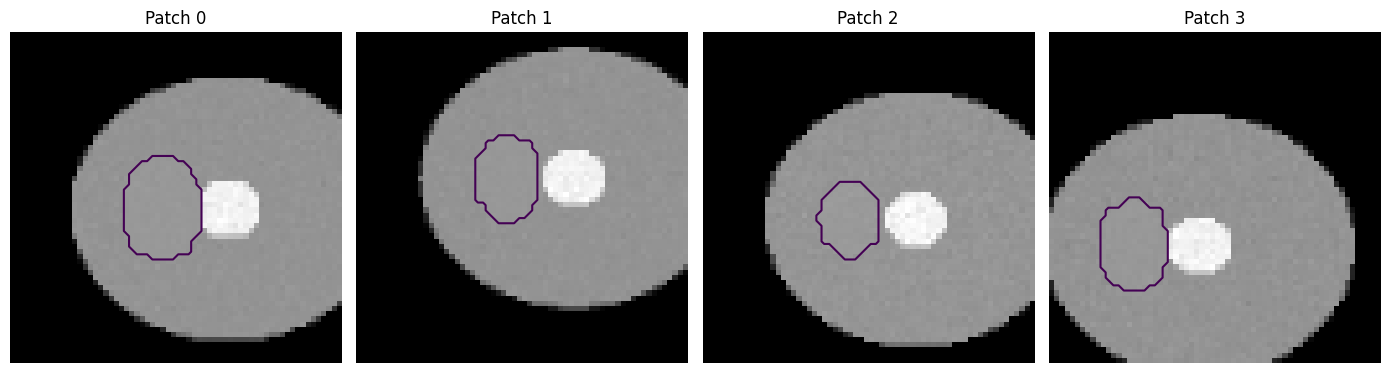

In [ ]:
fig, axes = plt.subplots(1, len(patches), figsize=(14, 4))

for i, (ax, patch) in enumerate(zip(axes, patches)):
    image = patch["image"][0].detach().cpu().numpy()
    label = patch["label"][0].detach().cpu().numpy()

    z = image.shape[2] // 2

    ax.imshow(image[:, :, z].T, cmap="gray", origin="lower")
    ax.contour(label[:, :, z].T, levels=[0.5])
    ax.set_title(f"Patch {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Exercise — connect sampling to the task

Consider three segmentation problems:

1. whole lung;
2. optic chiasm;
3. a very small metastatic lesion.

Would you use the same patch-sampling strategy for all three?

Why or why not?

There is no universally correct `pos:neg` ratio. It is part of the model-development strategy and should reflect the task.

# 7. `Dataset`, `CacheDataset`, and `DataLoader`

At this point we have:

```text
list of cases
+
transform pipeline
```

MONAI's `Dataset` connects them:

```text
dataset[index]
      ↓
find case
      ↓
apply transforms
      ↓
return transformed sample
```

For large 3D images, repeatedly loading and resampling data can become a training bottleneck. MONAI therefore also provides caching strategies.

## `CacheDataset`

`CacheDataset` can store the results of deterministic transforms that occur before the first random transform.

For our pipeline:

```text
Load
Orientation
Spacing
Intensity scaling
        ↓
      CACHE
        ↓
Random crop
Random flip
Random rotation
```

Expensive deterministic work can therefore be reused across epochs, while random augmentation remains stochastic.

> **Preprocessing should be reproducible; augmentation should remain variable during training.**

For this lesson, understanding that principle is more important than the details of cache tuning.

In [ ]:
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),

    Spacingd(
        keys=["image", "label"],
        pixdim=(1.5, 1.5, 2.0),
        mode=("bilinear", "nearest"),
    ),

    ScaleIntensityRanged(
        keys=["image"],
        a_min=-1000,
        a_max=1000,
        b_min=0.0,
        b_max=1.0,
        clip=True,
    ),

    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(64, 64, 32),
        pos=1,
        neg=1,
        num_samples=4,
    ),

    RandFlipd(
        keys=["image", "label"],
        prob=0.5,
        spatial_axis=0,
    ),

    RandRotate90d(
        keys=["image", "label"],
        prob=0.5,
        max_k=3,
        spatial_axes=(0, 1),
    ),

    EnsureTyped(keys=["image", "label"]),
])

train_ds = CacheDataset(
    data=files[:3],
    transform=train_transforms,
    cache_rate=1.0,
    num_workers=2,
)

print("Training cases:", len(train_ds))

Loading dataset: 100%|██████████| 3/3 [00:00<00:00, 12.09it/s]

Training cases: 3


## `DataLoader`

The `DataLoader` performs the familiar job from Lesson 2:

- requests items from the dataset;
- groups the resulting tensors into batches;
- optionally shuffles training cases.

Because `RandCropByPosNegLabeld` returns four patches per selected case, a `batch_size=1` case can produce four model inputs.

Remember that these four patches are four training examples, **not four independent patients**.

In [ ]:
train_loader = DataLoader(
    train_ds,
    batch_size=1,
    shuffle=True,
    num_workers=0,
)

batch = next(iter(train_loader))

print("Image batch shape:", batch["image"].shape)
print("Label batch shape:", batch["label"].shape)

Image batch shape: torch.Size([4, 1, 64, 64, 32])
Label batch shape: torch.Size([4, 1, 64, 64, 32])


Interpret a result such as:

```text
[4, 1, 64, 64, 32]
```

as:

```text
4 sampled patches
1 channel
64 × 64 × 32 voxels
```

The pipeline has now converted:

```text
NIfTI files
    ↓
spatially standardized images
    ↓
task-aware random patches
    ↓
batched PyTorch tensors
```

That is exactly what a 3D model can consume.

# 8. Training and validation should not use the same transform pipeline

Training benefits from stochastic variation:

```text
random crops
random flips
random rotations
```

Validation should estimate performance on a **stable, reproducible representation**.

We therefore usually separate:

```text
train_transforms
validation_transforms
```

Random augmentation normally belongs in the training pipeline, while deterministic preprocessing used to define the model input is shared with validation and future inference.

In [ ]:
val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),

    Spacingd(
        keys=["image", "label"],
        pixdim=(1.5, 1.5, 2.0),
        mode=("bilinear", "nearest"),
    ),

    ScaleIntensityRanged(
        keys=["image"],
        a_min=-1000,
        a_max=1000,
        b_min=0.0,
        b_max=1.0,
        clip=True,
    ),

    EnsureTyped(keys=["image", "label"]),
])

val_ds = Dataset(
    data=files[3:],
    transform=val_transforms,
)

val_sample = val_ds[0]

print("Validation image:", val_sample["image"].shape)
print("Validation label:", val_sample["label"].shape)

Validation image: torch.Size([1, 71, 71, 48])
Validation label: torch.Size([1, 71, 71, 48])


A later segmentation lesson will introduce another practical issue:

> Training may use small patches, but how do we make a prediction over an entire 3D validation image?

MONAI provides tools such as **sliding-window inference** for that purpose.

For now, the important principle is:

> **Training transforms create useful variation. Validation transforms should create a stable and reproducible evaluation representation.**

# 9. Exercise — design a MONAI pipeline for dose prediction

Return to the particle-therapy dose-prediction problem.

Suppose each case contains:

```python
case = {
    "ct": ...,
    "ptv": ...,
    "oar_1": ...,
    "oar_2": ...,
    "dose": ...,
}
```

For each preprocessing step, decide **which keys it should act on and how**.

### Orientation

Should changing orientation affect:

```text
CT?
PTV?
OARs?
dose?
```

### Resampling

Which interpolation would you choose for:

```text
CT        → ?
PTV       → ?
OAR       → ?
dose      → ?
```

### CT intensity scaling

Should it affect:

```text
CT?
masks?
dose?
```

### Random spatial augmentation

If the CT is rotated during training, what must happen to:

```text
PTV?
OARs?
dose target?
```

### Prescription and beam information

Are these naturally represented as image channels?

Or might they require:

- normalization;
- a constant-valued spatial channel;
- engineered spatial maps;
- another model-input branch;
- a different formulation of the prediction task?

> **A MONAI pipeline is not simply a list of transforms. It is an executable statement of how you have chosen to represent the learning problem.**

## Possible input-channel construction

After loading and preprocessing aligned spatial objects, MONAI can combine them into a model input.

Conceptually:

```text
CT ─────────┐
PTV ────────┤
OAR 1 ──────┼──→ concatenate along channel dimension
OAR 2 ──────┘

                ↓

[4, X, Y, Z]
```

The dose remains the target rather than an input channel.

This connects directly to Lesson 2:

```text
in_channels = number of spatial input feature maps
```

The difficult part is not the concatenation.

The difficult part is deciding **which information should be present and what representation is appropriate for it**.

# 10. Exit check

You should now be able to explain:

1. What a transform is and what a data pipeline is.
2. Why MONAI commonly represents cases as dictionaries.
3. What the `d` suffix in transforms such as `Spacingd` means.
4. What a `MetaTensor` adds to an ordinary tensor.
5. Why CT and segmentation masks use different interpolation modes.
6. Why spatial augmentations must remain synchronized across aligned objects.
7. Why not every transform should act on every key.
8. How patch sampling changes the effective training distribution.
9. Why many patches do not imply many independent patients.
10. What `Dataset`, `CacheDataset`, and `DataLoader` contribute.
11. Why training and validation usually use different transform pipelines.

# 11. Bridge to Lesson 4

We now have the pieces required to train a medical-image model:

```text
files
↓
MONAI transforms
↓
Dataset / CacheDataset
↓
DataLoader
↓
model-ready tensors
```

Lesson 4 can therefore focus on a complete task:

> **3D segmentation with MONAI**

We will reuse the same concepts rather than starting again:

- the same dictionaries;
- the same transforms;
- the same PyTorch training loop;
- a 3D segmentation network;
- a segmentation-specific loss;
- clinically meaningful evaluation.

# Optional self-study — use a real public 3D dataset

The Medical Segmentation Decathlon (MSD) **Task09 Spleen** dataset is a common MONAI teaching dataset for 3D CT segmentation.

MONAI can download it directly through `DecathlonDataset`.

The full archive is large enough that downloading it would dominate a short teaching session, so this section is intentionally **outside the core lesson**.

```python
from monai.apps import DecathlonDataset

real_dataset = DecathlonDataset(
    root_dir="/content/msd",
    task="Task09_Spleen",
    section="training",
    transform=val_transforms,
    download=True,
    cache_rate=0.0,
)
```

The transform concepts used in this notebook transfer directly to that dataset.

---

## References and further reading

- MONAI documentation: https://docs.monai.io/
- MONAI tutorials: https://github.com/Project-MONAI/tutorials
- MONAI 3D segmentation examples use dictionary transforms such as `LoadImaged`, `EnsureChannelFirstd`, `Spacingd`, and foreground-aware random cropping.
- MONAI `CacheDataset` caches deterministic processing before the first random transform so that expensive preprocessing does not need to be repeated every epoch.
- Medical Segmentation Decathlon: https://medicaldecathlon.com/

This notebook is educational material and is not intended for clinical use.